In [1]:
# --- Libraries with a short description ---
import pandas as pd # for data manipulation
import matplotlib.pyplot as plt # for plotting
import numpy as np #for numeric calculations and making simulated data.
import seaborn as sns # for plotting, an extension on matplotlib

# - sklearn has many data analysis utility functions like scaling as well as a large variety of modeling tools.
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import minmax_scale
from sklearn.preprocessing import scale
from sklearn.manifold import TSNE

# classes and functions for clustering exercises
from matplotlib.patches import Ellipse
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score


In [2]:

# Load the dataset
data_path = "shopping_centre.csv" #if you just give the name of the file it will look for the data in the same folder as your script
data = pd.read_csv(data_path, dtype = {'customer_id':'category',
                                       'gender':'category',
                                       'age': 'int',
                                       'income': 'float',
                                       'spending_score':'int'})
# 1. Print the first five rows
print(data.head())

# 2. Create feature lists
numeric_features = ['age', 'income', 'spending_score']
categorical_features = ['gender']

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

  customer_id  gender  age  income  spending_score
0        0001    Male   19    15.0              39
1        0002    Male   21    15.0              81
2        0003  Female   20    16.0               6
3        0004  Female   23    16.0              77
4        0005  Female   31    17.0              40
Numeric features: ['age', 'income', 'spending_score']
Categorical features: ['gender']


In [3]:

print(data.dtypes)


customer_id       category
gender            category
age                  int32
income             float64
spending_score       int32
dtype: object


In [4]:

data.describe()



,age,income,spending_score
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [8]:

print(data['gender'].describe())


count        200
unique         3
top       Female
freq         112
Name: gender, dtype: object


In [9]:
print(data[categorical_features].describe())

        gender
count      200
unique       3
top     Female
freq       112


In [10]:
# read in the dataset with no arguments
wrongly_read_data = pd.read_csv("shopping_centre.csv")

# calculate descriptives for the data that was wrongly read in.
wrongly_read_data.describe()




,customer_id,age,income,spending_score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


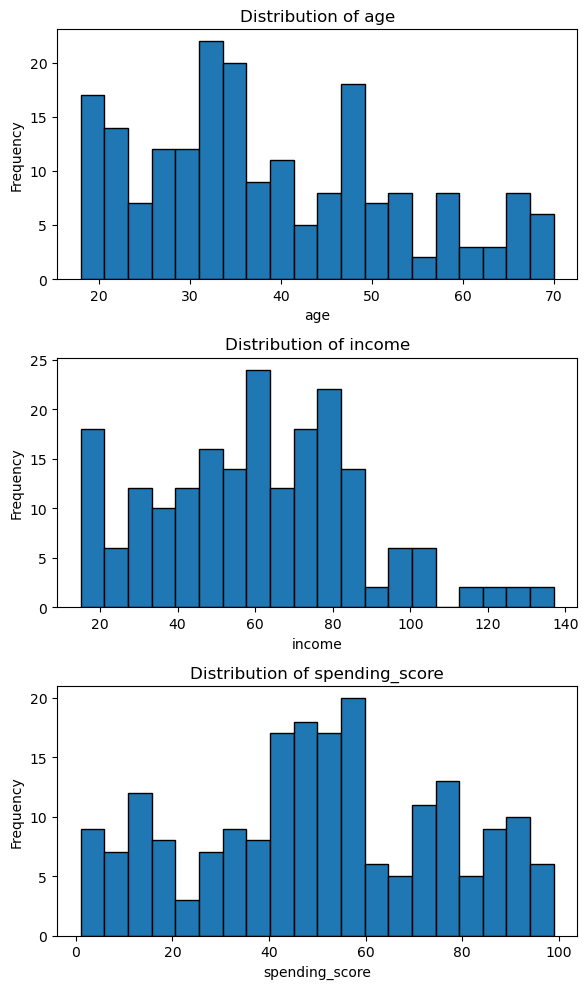

In [11]:


import matplotlib.pyplot as plt

# Create subplots — one for each numeric feature
fig, axes = plt.subplots(3, figsize=(6, 10))

# Loop through numeric features and plot histograms
for i, feature in enumerate(numeric_features):
    axes[i].hist(data[feature], bins=20, edgecolor='black')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


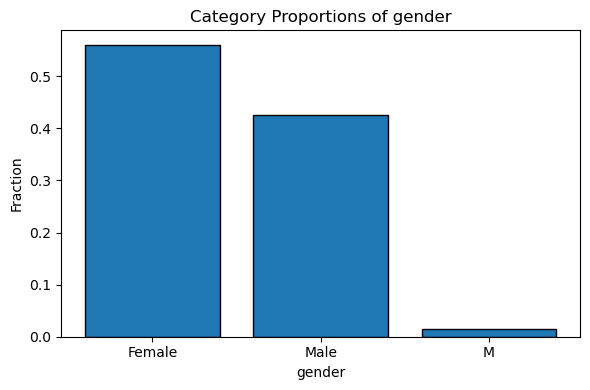

In [12]:


# Create subplots — one for each categorical feature
fig, axes = plt.subplots(len(categorical_features), figsize=(6, 4))

# If only one categorical feature, axes is not a list — fix by making it iterable
if len(categorical_features) == 1:
    axes = [axes]

# Loop through categorical features and plot bar charts
for i, feature in enumerate(categorical_features):
    fractions = data[feature].value_counts(normalize=True)  # relative frequencies
    axes[i].bar(fractions.index, fractions.values, edgecolor='black')
    axes[i].set_title(f'Category Proportions of {feature}')
    axes[i].set_ylabel('Fraction')
    axes[i].set_xlabel(feature)

plt.tight_layout()
plt.show()


In [13]:



# Remove the leftover unused category (if still present)
data['gender'] = data['gender'].cat.remove_categories("M")





In [14]:


# Create age category feature using 5 demographic groups
bins = [0, 22, 29, 39, 49, 100]  # age boundaries
labels = ['Under 23', '23-29', '30-39', '40-49', '50+']  # category names

data['age_category'] = pd.cut(data['age'], bins=bins, labels=labels)

# Verify the new feature
print(data[['age', 'age_category']])




     age age_category
0     19     Under 23
1     21     Under 23
2     20     Under 23
3     23        23-29
4     31        30-39
..   ...          ...
195   35        30-39
196   45        40-49
197   32        30-39
198   32        30-39
199   30        30-39

[200 rows x 2 columns]


In [15]:


# Create income category feature using 5 earning groups
bins = [0, 40, 70, 100, 130, 200]   # income boundaries (in thousands)
labels = ['Low', 'Below Average', 'Average', 'Above Average', 'High']

data['income_category'] = pd.cut(data['income'], bins=bins, labels=labels)

# Verify the new feature
print(data[['income', 'income_category']])


     income income_category
0      15.0             Low
1      15.0             Low
2      16.0             Low
3      16.0             Low
4      17.0             Low
..      ...             ...
195   120.0   Above Average
196   126.0   Above Average
197   126.0   Above Average
198   137.0            High
199   137.0            High

[200 rows x 2 columns]


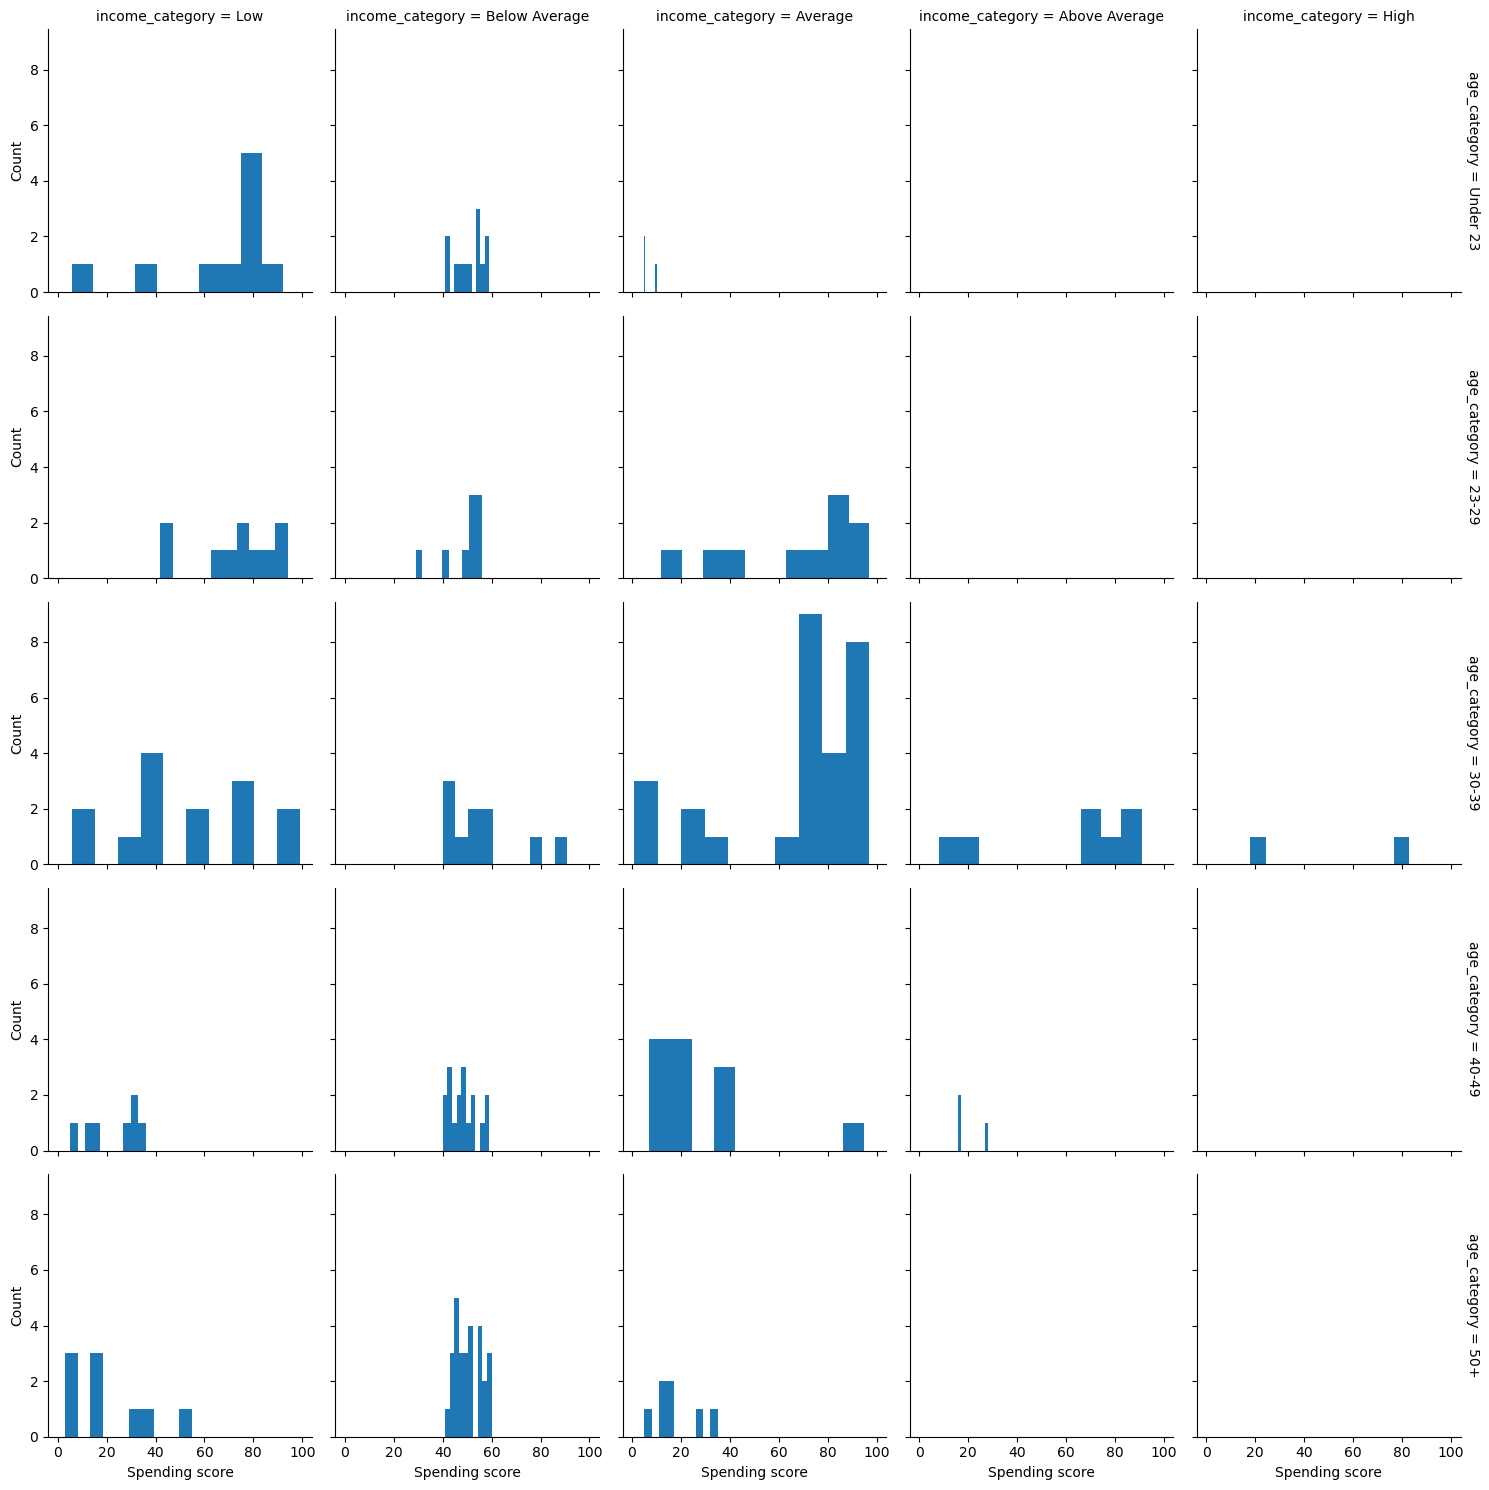

In [16]:

import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    data,
    row="age_category",
    col="income_category",
    height=3,
    margin_titles=True,
    sharex=True,
    sharey=True
)

g.map(plt.hist, "spending_score", bins=10)
g.set_axis_labels("Spending score", "Count")
plt.tight_layout()
plt.show()


In [17]:


from sklearn.preprocessing import minmax_scale
import pandas as pd

# Apply Min-Max scaling to numeric features
scaled_values = minmax_scale(data[numeric_features])

# Put the scaled values back into a new dataframe
data_min_maxed = pd.DataFrame(scaled_values, columns=numeric_features)

# Preview
print(data_min_maxed)


          age    income  spending_score
0    0.019231  0.000000        0.387755
1    0.057692  0.000000        0.816327
2    0.038462  0.008197        0.051020
3    0.096154  0.008197        0.775510
4    0.250000  0.016393        0.397959
..        ...       ...             ...
195  0.326923  0.860656        0.795918
196  0.519231  0.909836        0.275510
197  0.269231  0.909836        0.744898
198  0.269231  1.000000        0.173469
199  0.230769  1.000000        0.836735

[200 rows x 3 columns]


In [18]:

from sklearn.preprocessing import scale
import pandas as pd

# Standardize numeric features (mean = 0, std = 1)
standardized_values = scale(data[numeric_features])

# Convert back to a DataFrame with original column names
data_standardized = pd.DataFrame(standardized_values, columns=numeric_features)

# Preview result
print(data_standardized)


          age    income  spending_score
0   -1.424569 -1.738999       -0.434801
1   -1.281035 -1.738999        1.195704
2   -1.352802 -1.700830       -1.715913
3   -1.137502 -1.700830        1.040418
4   -0.563369 -1.662660       -0.395980
..        ...       ...             ...
195 -0.276302  2.268791        1.118061
196  0.441365  2.497807       -0.861839
197 -0.491602  2.497807        0.923953
198 -0.491602  2.917671       -1.250054
199 -0.635135  2.917671        1.273347

[200 rows x 3 columns]


C:\Users\molli\AppData\Local\Temp\ipykernel_23308\1981781582.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data_min_maxed[numeric_features].values, labels=numeric_features)
C:\Users\molli\AppData\Local\Temp\ipykernel_23308\1981781582.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_standardized[numeric_features].values, labels=numeric_features)


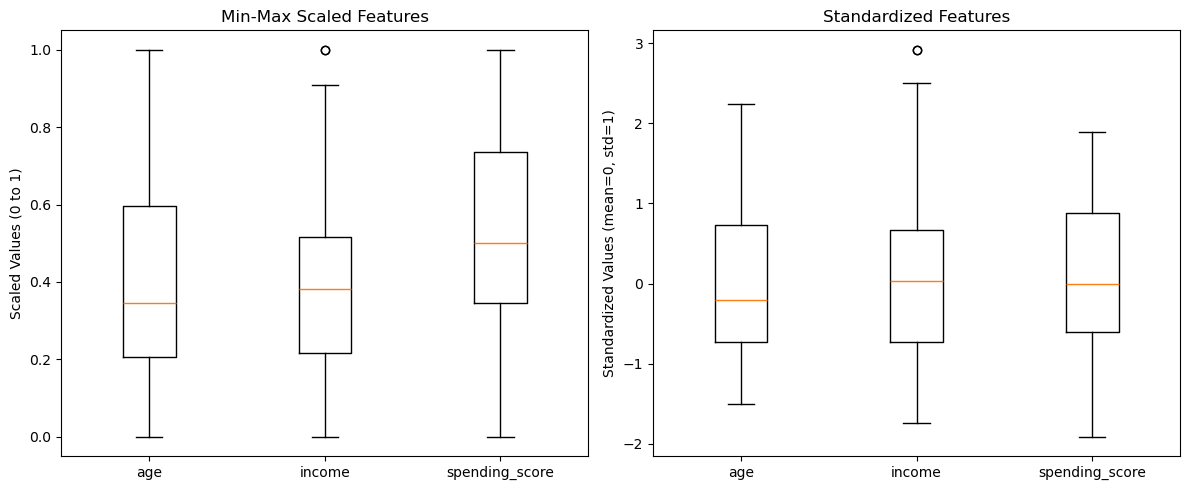

In [19]:


import matplotlib.pyplot as plt

# Create a figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot for Min-Max scaled data
axes[0].boxplot(data_min_maxed[numeric_features].values, labels=numeric_features)
axes[0].set_title("Min-Max Scaled Features")
axes[0].set_ylabel("Scaled Values (0 to 1)")

# Boxplot for Standardized data
axes[1].boxplot(data_standardized[numeric_features].values, labels=numeric_features)
axes[1].set_title("Standardized Features")
axes[1].set_ylabel("Standardized Values (mean=0, std=1)")

plt.tight_layout()
plt.show()


In [20]:


### Add an outlier, DONT CHANGE THIS CELL CODE, JUST RUN IT ###
data_w_outlier = data.copy()  # data should be the original dataset
data_w_outlier.loc[data.shape[0] - 1, 'age'] = 150  # replace last age value with 150 (outlier)
age_w_outlier = data_w_outlier.age  # extract updated age column


from sklearn.preprocessing import minmax_scale, scale

# 1) Min-Max scale the age feature containing the outlier
age_w_outlier_minmaxed = minmax_scale(age_w_outlier)

# 2) Standardize the same feature
age_w_outlier_standardized = scale(age_w_outlier)

# Optional — preview results
print(age_w_outlier_minmaxed[:5])
print(age_w_outlier_standardized[:5])



[0.00757576 0.02272727 0.01515152 0.03787879 0.09848485]
[-1.2801832  -1.15498191 -1.21758255 -1.02978062 -0.52897545]


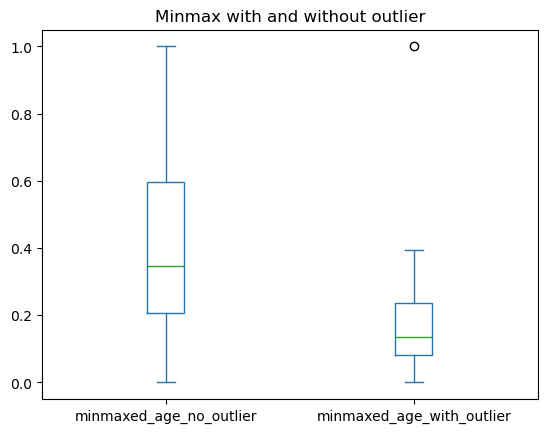

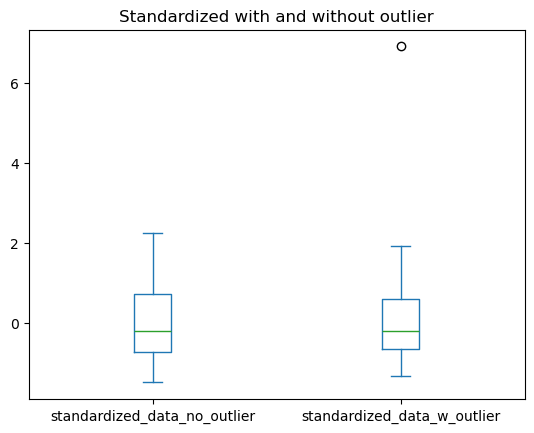

In [21]:

# Wrap in a dataframe that will have two features - the age feature without the outlier, and the age feature with it, min-maxed.
minmaxed_outlier_example = pd.DataFrame({"minmaxed_age_no_outlier" : data_min_maxed.age,
              "minmaxed_age_with_outlier": age_w_outlier_minmaxed })

# Wrap in a dataframe that will have two features - the age feature without the outlier, and the age feature with it, standardized.
standardized_outlier_example = pd.DataFrame({"standardized_data_no_outlier" : data_standardized.age,
              "standardized_data_w_outlier": age_w_outlier_standardized })

axes_minmaxed = minmaxed_outlier_example[['minmaxed_age_no_outlier', 'minmaxed_age_with_outlier']].plot(kind='box', title='Minmax with and without outlier')
axes_std = standardized_outlier_example[['standardized_data_no_outlier', 'standardized_data_w_outlier']].plot(kind='box', title='Standardized with and without outlier')

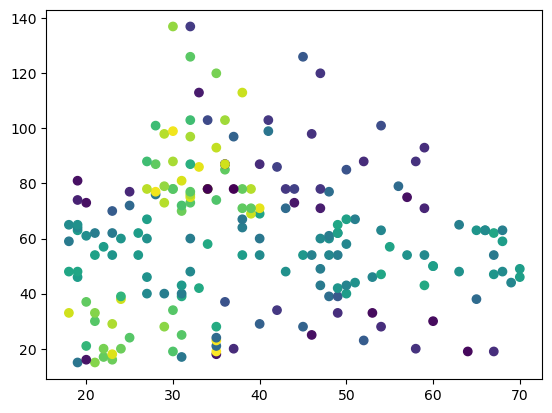

In [42]:
fig, ax = plt.subplots()
ax.scatter(data["age"], data["income"], c=data["spending_score"])

In [22]:


from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Use standardized numeric data for clustering
X = data_standardized[numeric_features].values

# Linkage methods to explore
linkage_methods = ["ward", "complete", "average", "single"]

# Dictionaries to store results
silhouette_results = {}
cluster_predictions = {}

# Test cluster counts from 2 to 10 for each linkage method
for linkage in linkage_methods:
    for n_clusters in range(2, 11):

        # Ward linkage automatically uses Euclidean distance
        if linkage == "ward":
            model = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
        else:
            # For other linkage types, specify metric instead of affinity
            model = AgglomerativeClustering(
                n_clusters=n_clusters,
                linkage=linkage,
                metric="euclidean"
            )
        
        # Fit model and get cluster assignments
        labels = model.fit_predict(X)
        
        # Compute silhouette score
        sil_score = silhouette_score(X, labels)
        
        # Store silhouette score and labels
        silhouette_results[(n_clusters, linkage)] = sil_score
        cluster_predictions[(n_clusters, linkage)] = labels


In [23]:


import pandas as pd

# Prepare a list to store the best result for each number of clusters
best_rows = []

# Loop over number of clusters from 2 to 10
for n_clusters in range(2, 11):
    best_linkage = None
    best_score = -1
    
    # Check all linkage methods for this number of clusters
    for linkage in linkage_methods:
        score = silhouette_results[(n_clusters, linkage)]
        
        # Keep track of the highest silhouette score for this n_clusters
        if score > best_score:
            best_score = score
            best_linkage = linkage
    
    # Store result as a row
    best_rows.append({
        "Number of clusters": n_clusters,
        "Linkage criterion": best_linkage,
        "Silhouette score": best_score
    })

# Create a DataFrame from the results
best_table = pd.DataFrame(best_rows)

# Sort by silhouette score (high to low)
best_table = best_table.sort_values("Silhouette score", ascending=False)

# Display the table
print(best_table)


   Number of clusters Linkage criterion  Silhouette score
4                   6              ward          0.420117
3                   5           average          0.409569
7                   9           average          0.406859
5                   7              ward          0.398295
8                  10           average          0.395443
2                   4          complete          0.390139
6                   8           average          0.375567
1                   3           average          0.339962
0                   2           average          0.324936


In [24]:


from sklearn.decomposition import PCA

# Use standardized numeric features as input to PCA
X = data_standardized[numeric_features].values

# Create PCA object to reduce to 2 principal components
pca = PCA(n_components=2)

# Project data into 2D space
X_pca = pca.fit_transform(X)

# Wrap into a DataFrame for easier use later (e.g., plotting)
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])




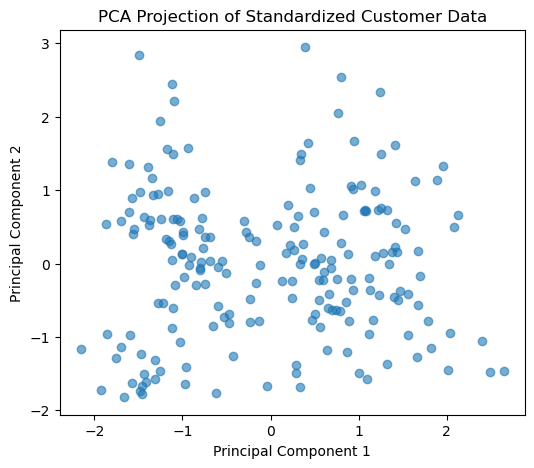

In [25]:


import matplotlib.pyplot as plt

# Scatter plot of PCA projection
plt.figure(figsize=(6, 5))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.6)

plt.title("PCA Projection of Standardized Customer Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


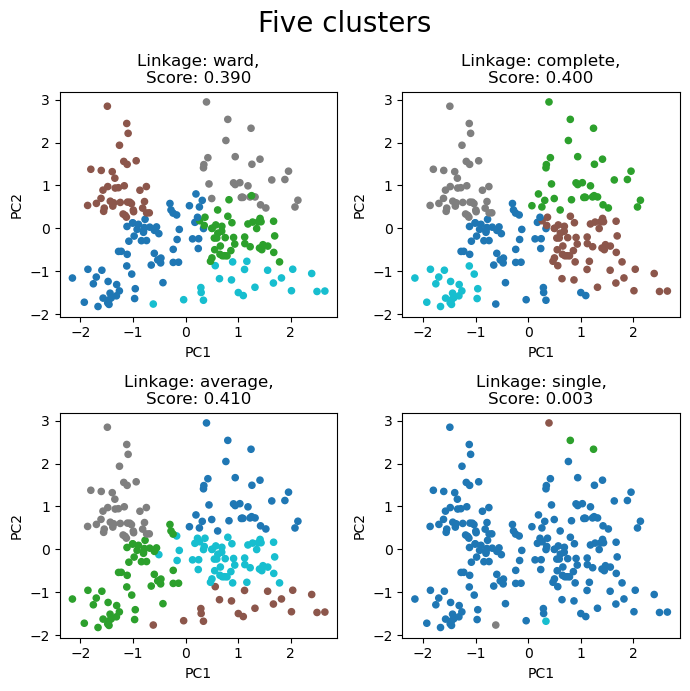

In [26]:


# list of linkage methods in the same order as plots
linkage_methods = ["ward", "complete", "average", "single"]

# outline for the plots
fig, axes = plt.subplots(2, 2, figsize=(7, 7))
fig.suptitle("Five clusters", fontsize=20)

axes = axes.flatten()  # creates a single array from a 2D-matrix

for i, ax in enumerate(axes):
    # pick the linkage method for this subplot
    linkage = linkage_methods[i]
    
    # get cluster labels and silhouette score for 5 clusters with this linkage
    labels = cluster_predictions[(5, linkage)]
    score = silhouette_results[(5, linkage)]
    
    # scatter plot the data points in the PCA space, color by cluster label
    ax.scatter(pca_df['PC1'], pca_df['PC2'], c=labels, cmap='tab10', s=20)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    
    # set subplot title with linkage method and silhouette score
    ax.set_title(f"Linkage: {linkage},\nScore: {score:.3f}")

plt.tight_layout()


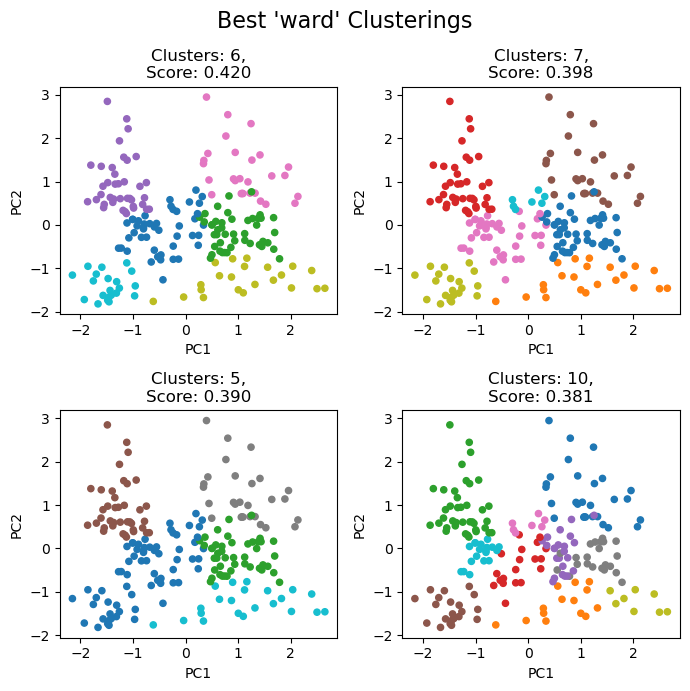

In [53]:

# Collect silhouette scores for 'ward' linkage for all n_clusters
ward_results = [
    (n_clusters, silhouette_results[(n_clusters, "ward")])
    for n_clusters in range(2, 11)
]

# Sort by silhouette score (high to low) and take the best four
ward_results_sorted = sorted(ward_results, key=lambda x: x[1], reverse=True)
best_ward = ward_results_sorted[:4]

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(7, 7))
fig.suptitle("Best 'ward' Clusterings", fontsize=16)
axes = axes.flatten()

# Plot each of the four best 'ward' clusterings
for ax, (n_clusters, score) in zip(axes, best_ward):
    labels = cluster_predictions[(n_clusters, "ward")]  # cluster assignments
    
    # Scatter in PCA space, colored by cluster
    ax.scatter(pca_df['PC1'], pca_df['PC2'], c=labels, cmap='tab10', s=20)
    ax.set_title(f"Clusters: {n_clusters},\nScore: {score:.3f}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()


In [27]:
# --- Your code for 9 a) ---
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# Use standardized numeric data for k-means
X = data_standardized[numeric_features].values

# Dictionaries to store results
kmeans_silhouette_results = {}   # k -> silhouette score
kmeans_centroids = {}            # k -> centroids in standardized feature space
kmeans_predictions = {}          # k -> cluster labels for each sample

# Try k from 2 to 10
for k in range(2, 11):
    # Create and fit k-means model
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(X)
    
    # Compute silhouette score
    sil_score = silhouette_score(X, labels)
    
    # Store results
    kmeans_silhouette_results[k] = sil_score
    kmeans_centroids[k] = kmeans.cluster_centers_
    kmeans_predictions[k] = labels


C:\Users\molli\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\molli\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\molli\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\molli\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

Best k values by silhouette score: [7, 5, 10, 8]


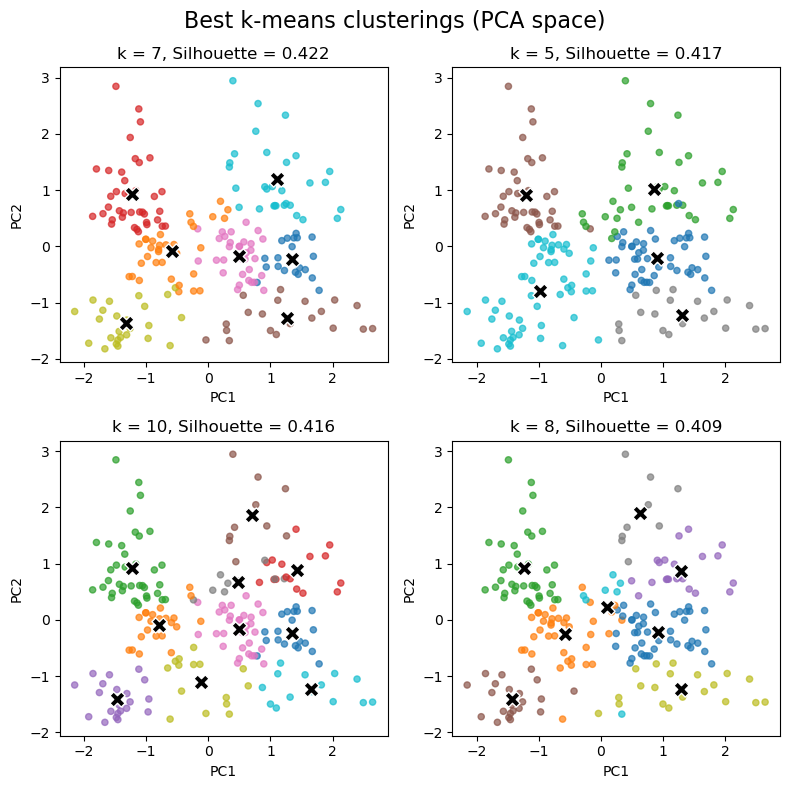

In [56]:



import matplotlib.pyplot as plt
import numpy as np

# 1) Choose the four best numbers of clusters according to silhouette coefficient
#    (from kmeans_silhouette_results computed in 9 a)

# Turn results into a list of (k, score) and sort by score descending
k_scores = sorted(kmeans_silhouette_results.items(), key=lambda x: x[1], reverse=True)

# Take the four best k values
best_k_values = [item[0] for item in k_scores[:4]]
print("Best k values by silhouette score:", best_k_values)

# 2) Prepare 2x2 subplot for visualization
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()
fig.suptitle("Best k-means clusterings (PCA space)", fontsize=16)

for ax, k in zip(axes, best_k_values):
    # Get labels and centroids in standardized feature space
    labels = kmeans_predictions[k]
    centroids = kmeans_centroids[k]   # shape: (k, n_features)
    
    # Transform centroids to PCA (2D) space
    centroids_pca = pca.transform(centroids)
    
    # Scatter plot of points in PCA space colored by cluster
    scatter = ax.scatter(
        pca_df["PC1"], 
        pca_df["PC2"], 
        c=labels, 
        cmap="tab10", 
        s=20, 
        alpha=0.7
    )
    
    # Plot centroids as larger markers
    ax.scatter(
        centroids_pca[:, 0], 
        centroids_pca[:, 1], 
        marker="X", 
        s=120, 
        c="black",
        edgecolor="white",
        linewidth=1.0,
        label="Centroids"
    )
    
    # Title with k and silhouette score
    score = kmeans_silhouette_results[k]
    ax.set_title(f"k = {k}, Silhouette = {score:.3f}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()


In [28]:
# --- Your code for 10 a) ---


import pandas as pd

# 1) Find the best clustering overall (highest silhouette score)
#    Compare agglomerative and k-means results
best_agglom = max(silhouette_results, key=silhouette_results.get)
best_kmeans = max(kmeans_silhouette_results, key=kmeans_silhouette_results.get)

# Get their scores
best_agglom_score = silhouette_results[best_agglom]
best_kmeans_score = kmeans_silhouette_results[best_kmeans]

# 2) Choose the better one based on silhouette score
if best_kmeans_score > best_agglom_score:
    best_method = "kmeans"
    best_k = best_kmeans
    labels = kmeans_predictions[best_k]
else:
    best_method = "agglomerative"
    best_k, best_linkage = best_agglom
    labels = cluster_predictions[(best_k, best_linkage)]

print(f"Best clustering method: {best_method}")
print(f"Number of clusters: {best_k}")

# 3) Create dataframe with cluster labels + numeric features
cluster_df = pd.concat(
    [pd.Series(labels, name="cluster"), data[numeric_features]],
    axis=1
)

cluster_df


Best clustering method: kmeans
Number of clusters: 7


,cluster,age,income,spending_score
0,5,19,15.0,39
1,5,21,15.0,81
2,3,20,16.0,6
3,5,23,16.0,77
4,3,31,17.0,40
...,...,...,...,...
195,2,35,120.0,79
196,6,45,126.0,28
197,2,32,126.0,74
198,6,32,137.0,18


In [29]:
# code to create the dataframe.
spending = pd.DataFrame({"cluster": labels, "spending": data["spending_score"],
                         "age": data["age"], "income": data["income"]})

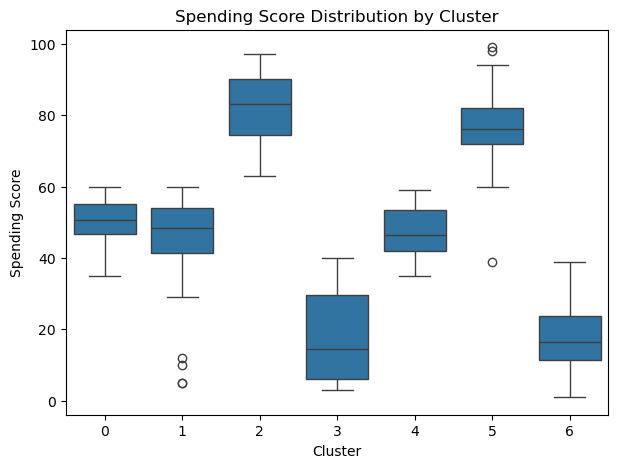

In [30]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.boxplot(x="cluster", y="spending", data=spending)

plt.title("Spending Score Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Spending Score")
plt.show()


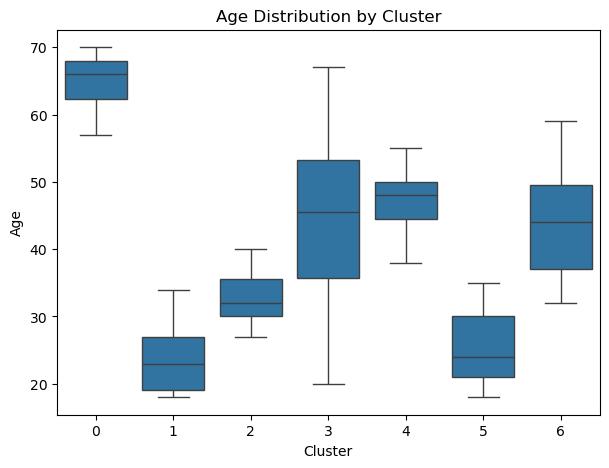

In [31]:

plt.figure(figsize=(7,5))
sns.boxplot(x="cluster", y="age", data=spending)

plt.title("Age Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Age")
plt.show()


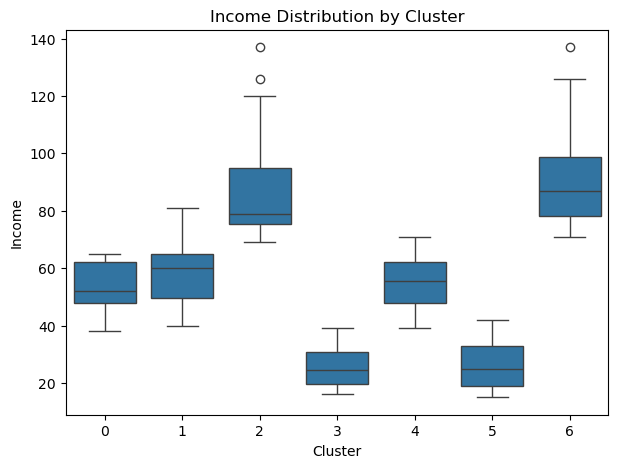

In [63]:

plt.figure(figsize=(7,5))
sns.boxplot(x="cluster", y="income", data=spending)

plt.title("Income Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Income")
plt.show()
